# 实验二 ConvLSTM 的算法应用与改进

本 Notebook 严格对应实验报告样板：环境、数据、基线配置、参数量手算核对、6 组控制变量实验、最优组合三次复测、预测帧九宫格及报告可用汇总。全部实验使用 CPU；实验二输出统一保存到 `lab02_outputs/`，避免覆盖实验一文件。

## 1 实验环境与随机种子

In [1]:
# 本机环境先加载 sklearn，可避免其与 PyTorch 的 OpenMP 运行库加载冲突。
import sklearn
import csv
import platform
import random
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
BEST_SEEDS = (42, 43, 44)
DEVICE = torch.device('cpu')
OUTPUT_DIR = Path('lab02_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
print('操作系统:', platform.platform())
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('NumPy:', np.__version__)
print('Matplotlib:', matplotlib.__version__)
print('CUDA 可用:', torch.cuda.is_available())
print('本实验设备:', DEVICE)

操作系统: Windows-10-10.0.26200-SP0
Python: 3.10.20
PyTorch: 2.5.1
NumPy: 2.0.1
Matplotlib: 3.10.9
CUDA 可用: False
本实验设备: cpu


## 2 数据合成

按指南正文生成 2000 条训练序列和 200 条独立测试序列，共 2200 条。每条包含 10 帧 32×32 图像，小球半径为 2，初速度绝对值为 0.8～1.6 像素/帧。

In [2]:
def make_sequences(n_seq=2200, total_frames=10, size=32, radius=2, seed=42):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size]
    sequences = np.zeros((n_seq, total_frames, size, size), dtype=np.uint8)

    for sequence_index in range(n_seq):
        x, y = rng.uniform(radius + 1, size - radius - 2, size=2)
        direction = rng.choice([-1.0, 1.0], size=2)
        vx, vy = direction * rng.uniform(0.8, 1.6, size=2)

        for frame_index in range(total_frames):
            x += vx
            y += vy
            if x < radius:
                x = 2 * radius - x
                vx = -vx
            elif x > size - 1 - radius:
                x = 2 * (size - 1 - radius) - x
                vx = -vx
            if y < radius:
                y = 2 * radius - y
                vy = -vy
            elif y > size - 1 - radius:
                y = 2 * (size - 1 - radius) - y
                vy = -vy
            sequences[sequence_index, frame_index] = (
                (xx - x) ** 2 + (yy - y) ** 2 <= radius ** 2
            )
    return sequences

all_sequences = torch.from_numpy(make_sequences(seed=SEED)).float().unsqueeze(2)
train_sequences = all_sequences[:2000]
test_sequences = all_sequences[2000:]
print('全部数据形状:', tuple(all_sequences.shape))
print('训练序列:', tuple(train_sequences.shape))
print('测试序列:', tuple(test_sequences.shape))
print('训练/测试是否分离:', train_sequences.data_ptr() != test_sequences.data_ptr())

全部数据形状: (2200, 10, 1, 32, 32)
训练序列: (2000, 10, 1, 32, 32)
测试序列: (200, 10, 1, 32, 32)
训练/测试是否分离: True


## 3 ConvLSTM 与全连接 LSTM 模型

In [3]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.gates = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size,
            padding=kernel_size // 2,
        )

    def forward(self, inputs, state):
        hidden, cell = state
        gates = self.gates(torch.cat([inputs, hidden], dim=1))
        input_gate, forget_gate, candidate, output_gate = gates.chunk(4, dim=1)
        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        output_gate = torch.sigmoid(output_gate)
        cell_new = forget_gate * cell + input_gate * torch.tanh(candidate)
        hidden_new = output_gate * torch.tanh(cell_new)
        return hidden_new, cell_new


class ConvLSTM(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=32, kernel_size=3, layers=1):
        super().__init__()
        channels = [input_channels] + [hidden_channels] * layers
        self.cells = nn.ModuleList([
            ConvLSTMCell(channels[index], channels[index + 1], kernel_size)
            for index in range(layers)
        ])
        self.output_conv = nn.Conv2d(hidden_channels, 1, 3, padding=1)

    def forward(self, inputs):
        batch_size, time_steps, _, height, width = inputs.shape
        states = [
            (
                inputs.new_zeros(batch_size, cell.hidden_channels, height, width),
                inputs.new_zeros(batch_size, cell.hidden_channels, height, width),
            )
            for cell in self.cells
        ]
        for time_index in range(time_steps):
            layer_inputs = inputs[:, time_index]
            for layer_index, cell in enumerate(self.cells):
                states[layer_index] = cell(layer_inputs, states[layer_index])
                layer_inputs = states[layer_index][0]
        return self.output_conv(states[-1][0])


class FlattenLSTM(nn.Module):
    def __init__(self, hidden_size=256, image_size=32):
        super().__init__()
        self.image_size = image_size
        pixels = image_size * image_size
        self.lstm = nn.LSTM(pixels, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, pixels)

    def forward(self, inputs):
        batch_size, time_steps = inputs.shape[:2]
        flattened = inputs.reshape(batch_size, time_steps, -1)
        sequence_output, _ = self.lstm(flattened)
        prediction = self.output(sequence_output[:, -1])
        return prediction.reshape(batch_size, 1, self.image_size, self.image_size)

## 4 参数量手算与代码核对

基线细胞：`4 × (3×3×1×32 + 3×3×32×32 + 32)`；输出卷积：`3×3×32×1 + 1`。本节同时给出报告思考题所需的 `C_h=64` 和全连接 LSTM 参数量。

In [4]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())

baseline_cell_hand = 4 * (3 * 3 * 1 * 32 + 3 * 3 * 32 * 32 + 32)
baseline_output_hand = 3 * 3 * 32 * 1 + 1
baseline_total_hand = baseline_cell_hand + baseline_output_hand
hidden64_cell_hand = 4 * (3 * 3 * 1 * 64 + 3 * 3 * 64 * 64 + 64)
hidden64_output_hand = 3 * 3 * 64 * 1 + 1

baseline_model_for_count = ConvLSTM()
hidden64_model_for_count = ConvLSTM(hidden_channels=64)
flatten_model_for_count = FlattenLSTM()

print('基线 ConvLSTM 细胞手算:', baseline_cell_hand)
print('基线输出卷积手算:', baseline_output_hand)
print('基线总参数量手算:', baseline_total_hand)
print('基线总参数量代码核对:', count_parameters(baseline_model_for_count))
print('C_h=64 单细胞参数量:', hidden64_cell_hand)
print('C_h=64 模型总参数量:', count_parameters(hidden64_model_for_count))
print('全连接 LSTM 总参数量:', count_parameters(flatten_model_for_count))
print('C_h=64 细胞/基线细胞倍数:', hidden64_cell_hand / baseline_cell_hand)
assert baseline_total_hand == count_parameters(baseline_model_for_count)

基线 ConvLSTM 细胞手算:

 38144
基线输出卷积手算: 289
基线总参数量手算: 38433
基线总参数量代码核对: 38433
C_h=64 单细胞参数量: 150016
C_h=64 模型总参数量: 150593
全连接 LSTM 总参数量: 1575936
C_h=64 细胞/基线细胞倍数: 3.9328859060402683


## 5 实验配置、训练、评估与绘图

基线为 1 层、`C_h=32`、`K=3`、看前 4 帧、MSE、Adam(0.001)、批量 64、5 epoch。实验 1～6 均从基线配置替换指南指定变量。

In [5]:
@dataclass(frozen=True)
class ExperimentConfig:
    key: str
    group: str
    name: str
    change: str
    model_type: str = 'convlstm'
    layers: int = 1
    hidden_channels: int = 32
    kernel_size: int = 3
    input_frames: int = 4
    loss_name: str = 'mse'
    learning_rate: float = 0.001
    batch_size: int = 64
    epochs: int = 5

BASELINE = ExperimentConfig('baseline', '0', '基线 Baseline', '1层，C_h=32，K=3，看4帧，MSE')
EXPERIMENTS = [
    BASELINE,
    replace(BASELINE, key='exp1', group='1', name='加深层数', change='1层 → 2层', layers=2),
    replace(BASELINE, key='exp2', group='2', name='隐藏通道', change='C_h: 32 → 64', hidden_channels=64),
    replace(BASELINE, key='exp3', group='3', name='卷积核', change='K: 3 → 5', kernel_size=5),
    replace(BASELINE, key='exp4', group='4', name='输入帧数', change='看4帧 → 看8帧', input_frames=8),
    replace(BASELINE, key='exp5', group='5', name='结构对照', change='ConvLSTM → 全连接LSTM', model_type='flatten_lstm'),
    replace(BASELINE, key='exp6', group='6', name='损失函数', change='MSE → L1', loss_name='l1'),
]

def build_model(config):
    if config.model_type == 'flatten_lstm':
        return FlattenLSTM()
    return ConvLSTM(
        hidden_channels=config.hidden_channels,
        kernel_size=config.kernel_size,
        layers=config.layers,
    )

def make_loaders(config, seed):
    train_x = train_sequences[:, :config.input_frames]
    train_y = train_sequences[:, config.input_frames]
    test_x = test_sequences[:, :config.input_frames]
    test_y = test_sequences[:, config.input_frames]
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        TensorDataset(train_x, train_y),
        batch_size=config.batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
    )
    test_loader = DataLoader(
        TensorDataset(test_x, test_y),
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
    )
    return train_loader, test_loader

def evaluate(model, data_loader):
    model.eval()
    squared_error = 0.0
    absolute_error = 0.0
    element_count = 0
    with torch.no_grad():
        for inputs, targets in data_loader:
            predictions = model(inputs.to(DEVICE))
            targets = targets.to(DEVICE)
            squared_error += (predictions - targets).pow(2).sum().item()
            absolute_error += (predictions - targets).abs().sum().item()
            element_count += targets.numel()
    return squared_error / element_count, absolute_error / element_count

def train_experiment(config, seed=42):
    set_seed(seed)
    model = build_model(config).to(DEVICE)
    loss_function = nn.MSELoss() if config.loss_name == 'mse' else nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    train_loader, test_loader = make_loaders(config, seed)
    history = {'train_loss': [], 'test_mse': [], 'test_mae': []}
    start_time = time.perf_counter()

    for epoch in range(config.epochs):
        model.train()
        epoch_loss = 0.0
        sample_count = 0
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = loss_function(predictions, targets)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * inputs.shape[0]
            sample_count += inputs.shape[0]
        train_loss = epoch_loss / sample_count
        test_mse, test_mae = evaluate(model, test_loader)
        history['train_loss'].append(train_loss)
        history['test_mse'].append(test_mse)
        history['test_mae'].append(test_mae)
        print(
            f'{config.key} epoch {epoch + 1}/{config.epochs} '
            f'train_loss={train_loss:.6f} test_MSE={test_mse:.6f} test_MAE={test_mae:.6f}'
        )
    elapsed = time.perf_counter() - start_time
    return model, history, elapsed

def save_history(config, history):
    path = OUTPUT_DIR / f'history_{config.key}.csv'
    with path.open('w', newline='', encoding='utf-8-sig') as file:
        writer = csv.writer(file)
        writer.writerow(['epoch', 'train_loss', 'test_mse', 'test_mae'])
        for index in range(config.epochs):
            writer.writerow([
                index + 1, history['train_loss'][index],
                history['test_mse'][index], history['test_mae'][index],
            ])

def save_curves(config, history, filename=None):
    epochs = range(1, config.epochs + 1)
    figure, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history['train_loss'], marker='o', label='训练损失')
    axes[0].set_title('训练损失曲线')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend()
    axes[1].plot(epochs, history['test_mse'], marker='o', label='测试 MSE')
    axes[1].plot(epochs, history['test_mae'], marker='s', label='测试 MAE')
    axes[1].set_title('测试误差曲线')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Error')
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    figure.suptitle(f'组 {config.group}：{config.name}')
    figure.tight_layout()
    output_name = filename or f'result_{config.key}.png'
    figure.savefig(OUTPUT_DIR / output_name, dpi=160, bbox_inches='tight')
    plt.show()
    plt.close(figure)

## 6 基线与六组对照实验

本单元会真实训练 7 个模型并保存 `result_baseline.png`、`result_exp1.png`～`result_exp6.png`、逐轮 CSV 和汇总 `results.csv`。


===== 组 0 基线 Baseline =====


baseline epoch 1/5 train_loss=0.011079 test_MSE=0.008957 test_MAE=0.024403


baseline epoch 2/5 train_loss=0.007111 test_MSE=0.006008 test_MAE=0.016619


baseline epoch 3/5 train_loss=0.005426 test_MSE=0.005328 test_MAE=0.014185


baseline epoch 4/5 train_loss=0.004976 test_MSE=0.005059 test_MAE=0.014202


baseline epoch 5/5 train_loss=0.004745 test_MSE=0.004857 test_MAE=0.014212


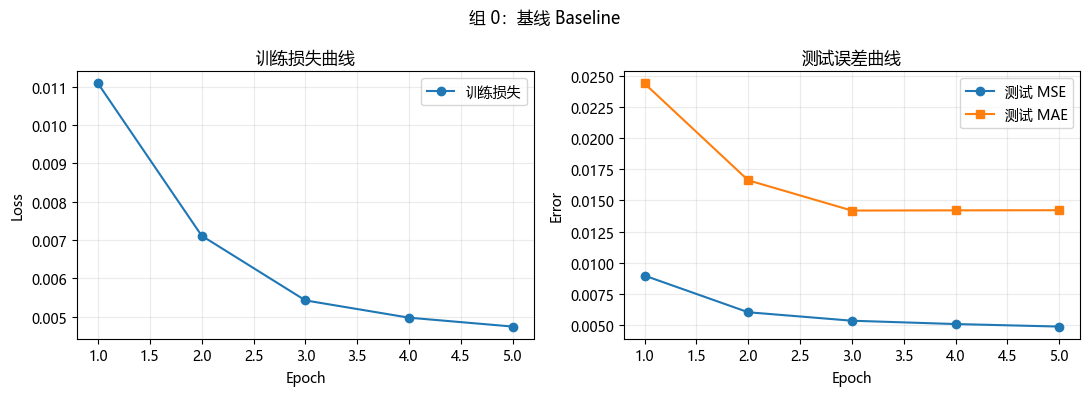

最终：MSE=0.004857, MAE=0.014212, 耗时=152.7s, 参数量=38,433

===== 组 1 加深层数 =====


exp1 epoch 1/5 train_loss=0.011048 test_MSE=0.007871 test_MAE=0.024739


exp1 epoch 2/5 train_loss=0.005627 test_MSE=0.005082 test_MAE=0.014911


exp1 epoch 3/5 train_loss=0.004717 test_MSE=0.004799 test_MAE=0.014151


exp1 epoch 4/5 train_loss=0.004511 test_MSE=0.004600 test_MAE=0.013804


exp1 epoch 5/5 train_loss=0.004166 test_MSE=0.004144 test_MAE=0.012727


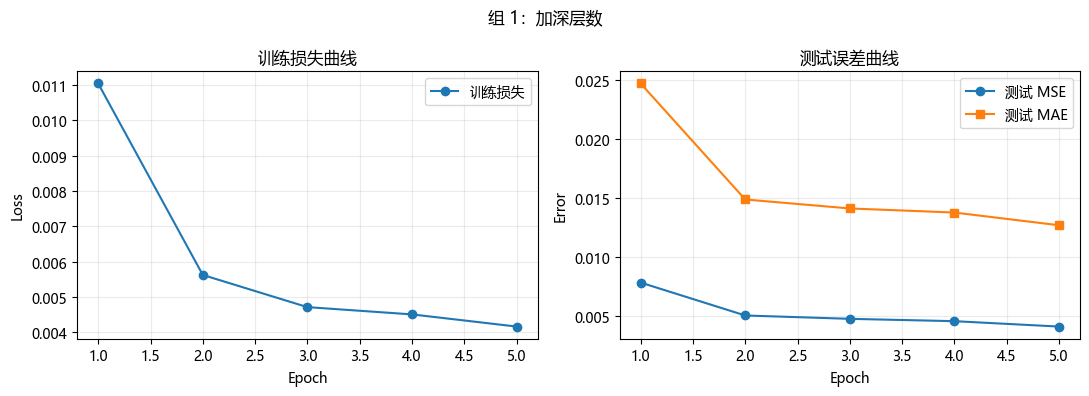

最终：MSE=0.004144, MAE=0.012727, 耗时=244.7s, 参数量=112,289

===== 组 2 隐藏通道 =====


exp2 epoch 1/5 train_loss=0.009561 test_MSE=0.006716 test_MAE=0.014842


exp2 epoch 2/5 train_loss=0.005534 test_MSE=0.005187 test_MAE=0.013998


exp2 epoch 3/5 train_loss=0.004820 test_MSE=0.004864 test_MAE=0.014141


exp2 epoch 4/5 train_loss=0.004592 test_MSE=0.004648 test_MAE=0.016942


exp2 epoch 5/5 train_loss=0.004362 test_MSE=0.004436 test_MAE=0.014423


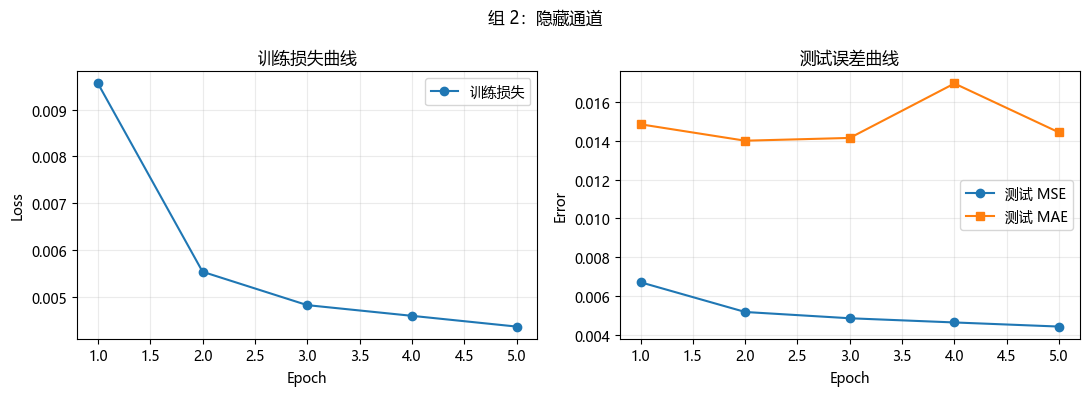

最终：MSE=0.004436, MAE=0.014423, 耗时=206.0s, 参数量=150,593

===== 组 3 卷积核 =====


exp3 epoch 1/5 train_loss=0.009858 test_MSE=0.006840 test_MAE=0.018796


exp3 epoch 2/5 train_loss=0.005352 test_MSE=0.004633 test_MAE=0.017140


exp3 epoch 3/5 train_loss=0.004349 test_MSE=0.004324 test_MAE=0.015132


exp3 epoch 4/5 train_loss=0.004140 test_MSE=0.004171 test_MAE=0.014981


exp3 epoch 5/5 train_loss=0.003964 test_MSE=0.004053 test_MAE=0.014372


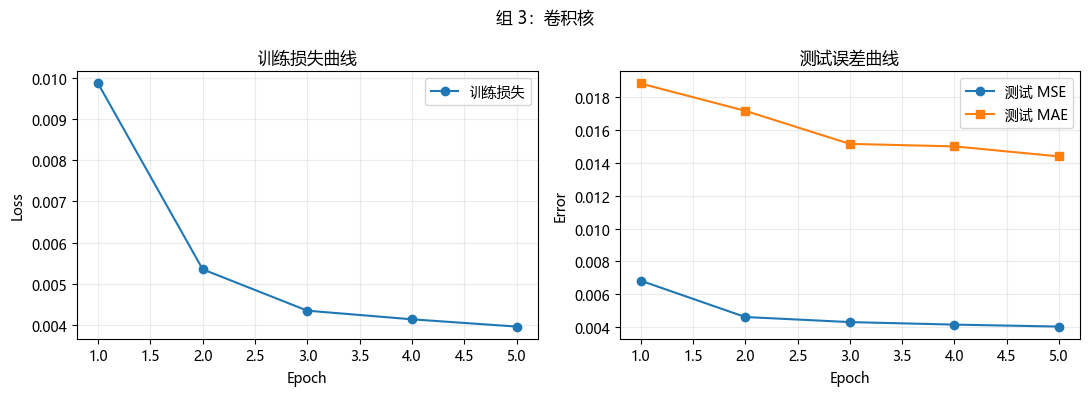

最终：MSE=0.004053, MAE=0.014372, 耗时=196.8s, 参数量=106,017

===== 组 4 输入帧数 =====


exp4 epoch 1/5 train_loss=0.011080 test_MSE=0.009052 test_MAE=0.022877


exp4 epoch 2/5 train_loss=0.007335 test_MSE=0.005997 test_MAE=0.018232


exp4 epoch 3/5 train_loss=0.005492 test_MSE=0.005133 test_MAE=0.016319


exp4 epoch 4/5 train_loss=0.004922 test_MSE=0.004768 test_MAE=0.013550


exp4 epoch 5/5 train_loss=0.004716 test_MSE=0.004705 test_MAE=0.020287


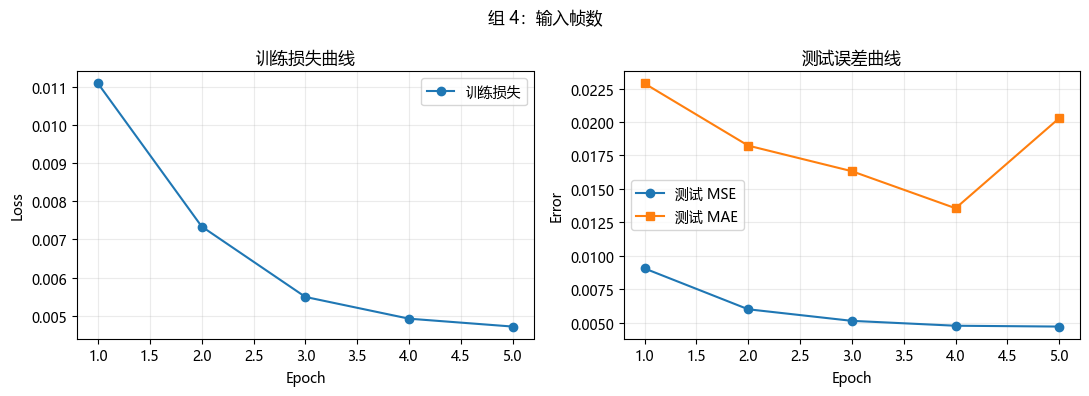

最终：MSE=0.004705, MAE=0.020287, 耗时=261.0s, 参数量=38,433

===== 组 5 结构对照 =====


exp5 epoch 1/5 train_loss=0.011857 test_MSE=0.010638 test_MAE=0.033516


exp5 epoch 2/5 train_loss=0.009819 test_MSE=0.009618 test_MAE=0.031685


exp5 epoch 3/5 train_loss=0.008744 test_MSE=0.008904 test_MAE=0.031776


exp5 epoch 4/5 train_loss=0.007855 test_MSE=0.008254 test_MAE=0.033064


exp5 epoch 5/5 train_loss=0.007069 test_MSE=0.007720 test_MAE=0.034454


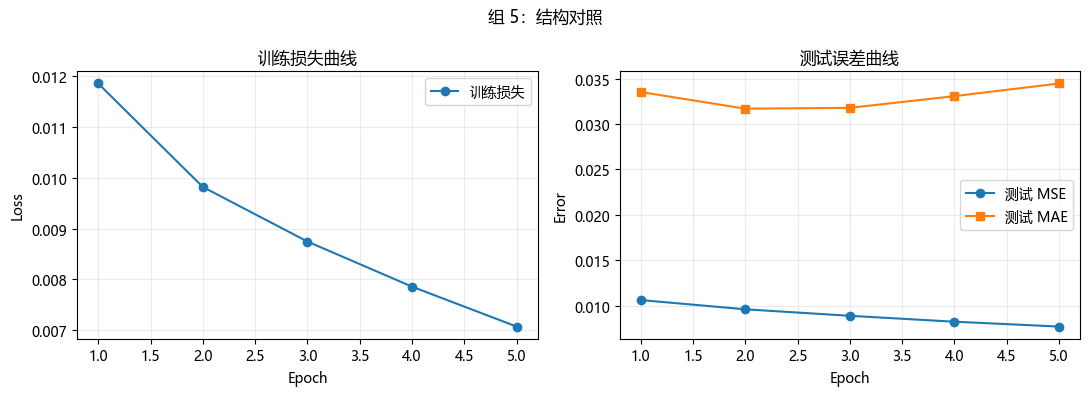

最终：MSE=0.007720, MAE=0.034454, 耗时=12.0s, 参数量=1,575,936

===== 组 6 损失函数 =====


exp6 epoch 1/5 train_loss=0.020463 test_MSE=0.012092 test_MAE=0.014262


exp6 epoch 2/5 train_loss=0.014180 test_MSE=0.012179 test_MAE=0.013616


exp6 epoch 3/5 train_loss=0.013858 test_MSE=0.012212 test_MAE=0.014148


exp6 epoch 4/5 train_loss=0.013933 test_MSE=0.012127 test_MAE=0.013145


exp6 epoch 5/5 train_loss=0.013604 test_MSE=0.012109 test_MAE=0.012998


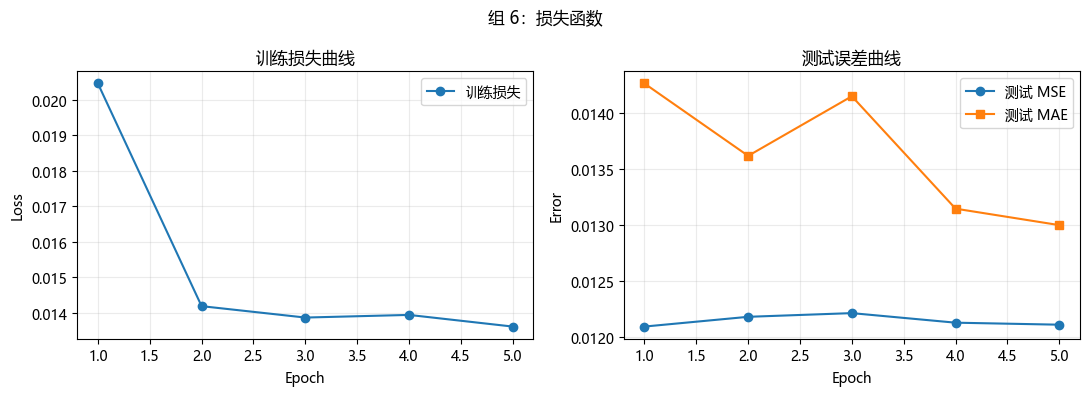

最终：MSE=0.012109, MAE=0.012998, 耗时=82.8s, 参数量=38,433


In [6]:
experiment_rows = []
retained_models = {}
all_histories = {}

for config in EXPERIMENTS:
    print(f'\n===== 组 {config.group} {config.name} =====')
    model, history, elapsed = train_experiment(config, SEED)
    save_history(config, history)
    save_curves(config, history)
    final_mse = history['test_mse'][-1]
    final_mae = history['test_mae'][-1]
    row = {
        'group': config.group,
        'key': config.key,
        'name': config.name,
        'change': config.change,
        'test_mse': final_mse,
        'test_mae': final_mae,
        'training_seconds': elapsed,
        'parameters': count_parameters(model),
        'seed': SEED,
    }
    experiment_rows.append(row)
    all_histories[config.key] = history
    if config.key in ('baseline', 'exp6'):
        retained_models[config.key] = model
    print(
        f'最终：MSE={final_mse:.6f}, MAE={final_mae:.6f}, '
        f'耗时={elapsed:.1f}s, 参数量={count_parameters(model):,}'
    )

with (OUTPUT_DIR / 'results.csv').open('w', newline='', encoding='utf-8-sig') as file:
    writer = csv.DictWriter(file, fieldnames=list(experiment_rows[0].keys()))
    writer.writeheader()
    writer.writerows(experiment_rows)

## 7 报告表 4 可直接核对的结果与逐组变化

In [7]:
baseline_mse = experiment_rows[0]['test_mse']
table_lines = [
    '|组号|实验名称|改动内容|MSE|MAE|耗时(s)|参数量|相对基线MSE变化|',
    '|---:|---|---|---:|---:|---:|---:|---:|',
]
for row in experiment_rows:
    relative_change = (row['test_mse'] - baseline_mse) / baseline_mse * 100
    table_lines.append(
        f"|{row['group']}|{row['name']}|{row['change']}|{row['test_mse']:.6f}|"
        f"{row['test_mae']:.6f}|{row['training_seconds']:.1f}|{row['parameters']:,}|"
        f"{relative_change:+.2f}%|"
    )
display(Markdown('\n'.join(table_lines)))
print('说明：相对基线MSE变化为负数表示误差下降、效果改善。')

|组号|实验名称|改动内容|MSE|MAE|耗时(s)|参数量|相对基线MSE变化|
|---:|---|---|---:|---:|---:|---:|---:|
|0|基线 Baseline|1层，C_h=32，K=3，看4帧，MSE|0.004857|0.014212|152.7|38,433|+0.00%|
|1|加深层数|1层 → 2层|0.004144|0.012727|244.7|112,289|-14.69%|
|2|隐藏通道|C_h: 32 → 64|0.004436|0.014423|206.0|150,593|-8.66%|
|3|卷积核|K: 3 → 5|0.004053|0.014372|196.8|106,017|-16.56%|
|4|输入帧数|看4帧 → 看8帧|0.004705|0.020287|261.0|38,433|-3.13%|
|5|结构对照|ConvLSTM → 全连接LSTM|0.007720|0.034454|12.0|1,575,936|+58.94%|
|6|损失函数|MSE → L1|0.012109|0.012998|82.8|38,433|+149.31%|

说明：相对基线MSE变化为负数表示误差下降、效果改善。


## 8 最优组合选择与三次复测

从层数、隐藏通道、卷积核、输入帧数和损失函数五项可组合改进中，按单项测试 MSE 下降幅度选择效果最明显的两项；全连接 LSTM 属于替代结构，不与 ConvLSTM 组合。三次复测使用预先固定的种子 42、43、44，并完整记录。

In [8]:
config_by_key = {config.key: config for config in EXPERIMENTS}
row_by_key = {row['key']: row for row in experiment_rows}
combinable_keys = ('exp1', 'exp2', 'exp3', 'exp4', 'exp6')
effective_keys = [
    key for key in combinable_keys
    if row_by_key[key]['test_mse'] < baseline_mse
]
selected_keys = sorted(effective_keys, key=lambda key: row_by_key[key]['test_mse'])[:2]
best_config = replace(BASELINE, key='best', group='7', name='最优组合')
for key in selected_keys:
    source = config_by_key[key]
    if key == 'exp1':
        best_config = replace(best_config, layers=source.layers)
    elif key == 'exp2':
        best_config = replace(best_config, hidden_channels=source.hidden_channels)
    elif key == 'exp3':
        best_config = replace(best_config, kernel_size=source.kernel_size)
    elif key == 'exp4':
        best_config = replace(best_config, input_frames=source.input_frames)
    elif key == 'exp6':
        best_config = replace(best_config, loss_name=source.loss_name)
best_config = replace(
    best_config,
    change=' + '.join(config_by_key[key].change for key in selected_keys),
)
print('单项有效改进:', effective_keys)
print('最优组合采用:', selected_keys)
print('最优组合配置:', asdict(best_config))

单项有效改进: ['exp1', 'exp2', 'exp3', 'exp4']
最优组合采用: ['exp3', 'exp1']
最优组合配置: {'key': 'best', 'group': '7', 'name': '最优组合', 'change': 'K: 3 → 5 + 1层 → 2层', 'model_type': 'convlstm', 'layers': 2, 'hidden_channels': 32, 'kernel_size': 5, 'input_frames': 4, 'loss_name': 'mse', 'learning_rate': 0.001, 'batch_size': 64, 'epochs': 5}



===== 最优组合第 1 次，seed=42 =====


best epoch 1/5 train_loss=0.009049 test_MSE=0.005723 test_MAE=0.020622


best epoch 2/5 train_loss=0.004484 test_MSE=0.004053 test_MAE=0.014051


best epoch 3/5 train_loss=0.003758 test_MSE=0.003746 test_MAE=0.013351


best epoch 4/5 train_loss=0.003454 test_MSE=0.003397 test_MAE=0.012538


...

best epoch 1/5 train_loss=0.008707 test_MSE=0.005300 test_MAE=0.019609


best epoch 2/5 train_loss=0.004328 test_MSE=0.004023 test_MAE=0.013587


best epoch 3/5 train_loss=0.003744 test_MSE=0.003665 test_MAE=0.012832


best epoch 4/5 train_loss=0.003408 test_MSE=0.003400 test_MAE=0.011426


best epoch 5/5 train_loss=0.003120 test_MSE=0.003194 test_MAE=0.011226
最优组合平均：MSE=0.003210 ± 0.000024, MAE=0.012370, 耗时=301.4s


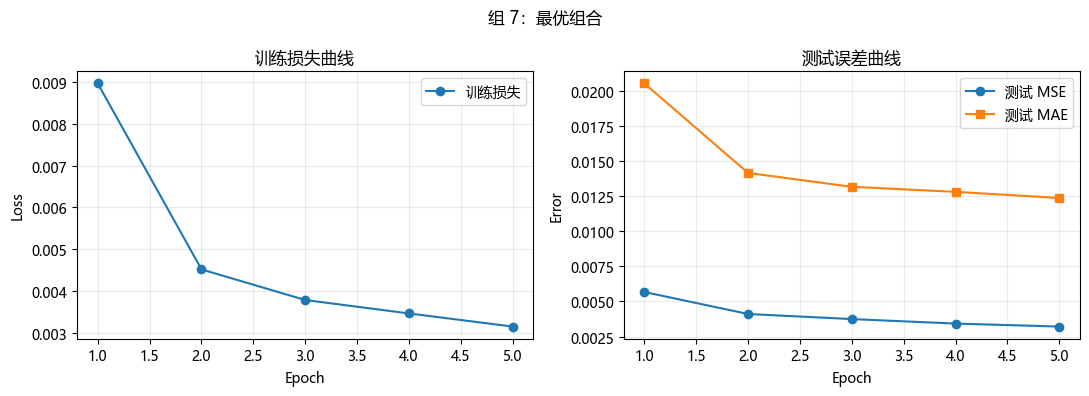

In [9]:
best_rows = []
best_histories = []
best_model_for_prediction = None
for run_number, seed in enumerate(BEST_SEEDS, start=1):
    print(f'\n===== 最优组合第 {run_number} 次，seed={seed} =====')
    model, history, elapsed = train_experiment(best_config, seed)
    best_histories.append(history)
    best_rows.append({
        'run': run_number,
        'seed': seed,
        'test_mse': history['test_mse'][-1],
        'test_mae': history['test_mae'][-1],
        'training_seconds': elapsed,
    })
    save_history(replace(best_config, key=f'best_run{run_number}'), history)
    if run_number == 1:
        best_model_for_prediction = model

with (OUTPUT_DIR / 'best_runs_results.csv').open('w', newline='', encoding='utf-8-sig') as file:
    writer = csv.DictWriter(file, fieldnames=list(best_rows[0].keys()))
    writer.writeheader()
    writer.writerows(best_rows)

mean_mse = float(np.mean([row['test_mse'] for row in best_rows]))
mean_mae = float(np.mean([row['test_mae'] for row in best_rows]))
mean_time = float(np.mean([row['training_seconds'] for row in best_rows]))
std_mse = float(np.std([row['test_mse'] for row in best_rows]))
print(f'最优组合平均：MSE={mean_mse:.6f} ± {std_mse:.6f}, MAE={mean_mae:.6f}, 耗时={mean_time:.1f}s')

mean_history = {
    metric: np.mean([history[metric] for history in best_histories], axis=0).tolist()
    for metric in ('train_loss', 'test_mse', 'test_mae')
}
save_curves(best_config, mean_history, filename='result_best.png')

## 9 预测帧九宫格与 L1/MSE 视觉对照

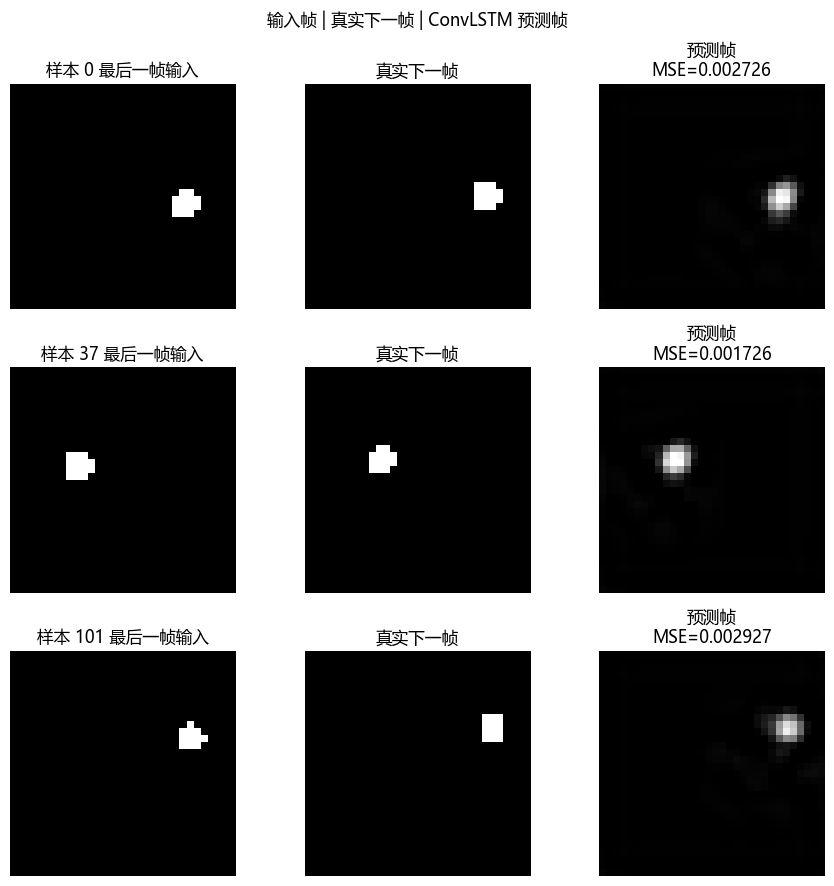

In [10]:
def predict_samples(model, config, indices=(0, 1, 2)):
    inputs = test_sequences[list(indices), :config.input_frames].to(DEVICE)
    targets = test_sequences[list(indices), config.input_frames].to(DEVICE)
    model.eval()
    with torch.no_grad():
        predictions = model(inputs)
    sample_mse = (predictions - targets).pow(2).flatten(1).mean(dim=1)
    return inputs.cpu(), targets.cpu(), predictions.cpu(), sample_mse.cpu()

sample_indices = (0, 37, 101)
inputs, targets, predictions, sample_mse = predict_samples(
    best_model_for_prediction, best_config, sample_indices
)
figure, axes = plt.subplots(3, 3, figsize=(9, 9))
for row_index, sample_index in enumerate(sample_indices):
    images = [
        inputs[row_index, -1, 0], targets[row_index, 0], predictions[row_index, 0].clamp(0, 1)
    ]
    titles = [
        f'样本 {sample_index} 最后一帧输入',
        '真实下一帧',
        f'预测帧\nMSE={sample_mse[row_index]:.6f}',
    ]
    for column_index, (image, title) in enumerate(zip(images, titles)):
        axes[row_index, column_index].imshow(image, cmap='gray', vmin=0, vmax=1)
        axes[row_index, column_index].set_title(title)
        axes[row_index, column_index].axis('off')
figure.suptitle('输入帧 | 真实下一帧 | ConvLSTM 预测帧')
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'result_pred.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(figure)

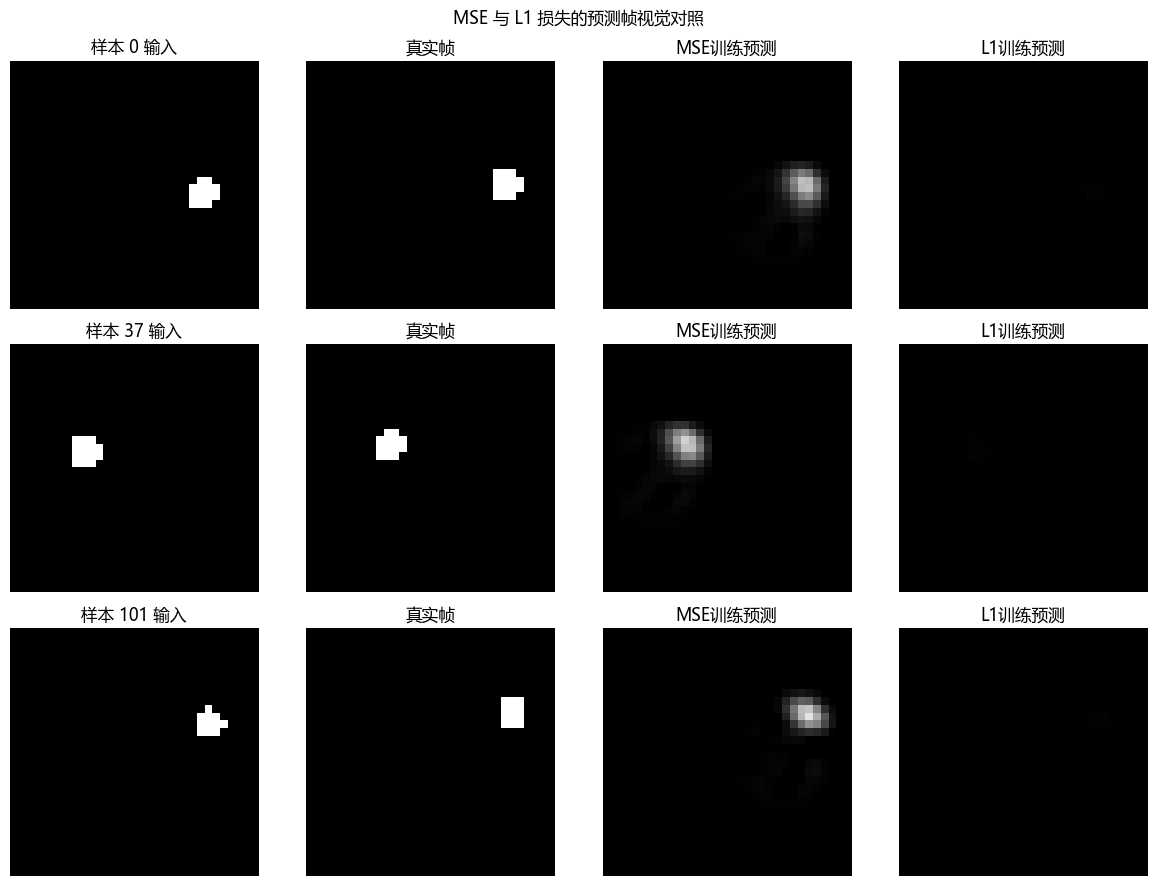

In [11]:
baseline_inputs, baseline_targets, baseline_predictions, _ = predict_samples(
    retained_models['baseline'], BASELINE, sample_indices
)
_, _, l1_predictions, _ = predict_samples(
    retained_models['exp6'], config_by_key['exp6'], sample_indices
)
figure, axes = plt.subplots(3, 4, figsize=(12, 9))
for row_index, sample_index in enumerate(sample_indices):
    images = [
        baseline_inputs[row_index, -1, 0], baseline_targets[row_index, 0],
        baseline_predictions[row_index, 0].clamp(0, 1), l1_predictions[row_index, 0].clamp(0, 1),
    ]
    titles = [f'样本 {sample_index} 输入', '真实帧', 'MSE训练预测', 'L1训练预测']
    for column_index, (image, title) in enumerate(zip(images, titles)):
        axes[row_index, column_index].imshow(image, cmap='gray', vmin=0, vmax=1)
        axes[row_index, column_index].set_title(title)
        axes[row_index, column_index].axis('off')
figure.suptitle('MSE 与 L1 损失的预测帧视觉对照')
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'result_exp6_pred_compare.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(figure)

## 10 报告填写核对清单与 CODEX 协作记录

运行完成后，报告表 1 使用第 1 节环境输出；表 2 使用基线配置；表 3 使用第 4 节参数量；表 4 使用第 7 节汇总；表 6 使用第 8 节三次复测；图 1～7、图 8 分别取自 `lab02_outputs/`。

真实 CODEX 协作可记录为：①依据指南和报告样板拆解实验输出项；②实现并核对 ConvLSTMCell 的四门卷积与状态更新；③建立共享数据、单变量配置、CSV和曲线保存流程；④发现指南参考代码训练/测试重叠风险，按正文改为 2000+200 独立序列；⑤为避免覆盖实验一，将实验二产物隔离到独立目录。采用前需结合本 Notebook 的真实运行输出自行核对。